# SICD — Semantic Interference & Cognitive Dissonance (camera-ready)

Stress-tests biomedical chain-of-thought reasoning under escalating semantic interference.

| Stage | Cell | What it does |
|-------|------|--------------|
| Setup | 0–4 | Fetch files (Colab), environment, API keys, imports, case overview |
| Generation | 5 | cases x 4 levels x temperatures {0.4, 0.7, 0.9} -> per-temp caches |
| Extraction + Scoring | 6 | UMLS concepts -> Density / Specificity / Oscillation / Regression / SDR |
| Evaluation | 7 | Spearman rho per temperature + ablation table + bootstrap CIs + per-case SDR |
| Visualization | 8 | Signal trajectories + SDR temperature-ablation overlay |

**Interference levels (harmonized prompts — identical across models):**
- Level 0 (Control): standard step-by-step diagnostic reasoning, no interference.
- Level 1 (Soft): "consider potential implications or differential considerations from the [interference domain] domain."
- Level 2 (Hard): "frame every step of your reasoning through the lens of [interference domain] pathophysiology and mechanisms."
- Level 3 (Full Dissonance): "explain why this presentation is actually a manifestation of [interference disease]."

**Oscillation note:** Oscillation is now *domain-frame* oscillation (target<->interference switching), reusing the SDR classifier. The earlier semantic-type oscillation was structurally pinned at 0 because the UMLS /search extraction never populates semantic types.


In [1]:
# -- Install dependencies (run once; self-repairs pip if missing) --------------
# Installs into THIS kernel's interpreter via sys.executable (more reliable than
# the %pip magic) and rebuilds pip with ensurepip if it is missing/broken.
import sys, subprocess
print("kernel python:", sys.executable)
subprocess.run([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
r = subprocess.run([sys.executable, "-m", "pip", "install",
                    "requests", "openai", "python-dotenv", "numpy", "scipy", "matplotlib", "pandas"])
print("pip install exit code:", r.returncode, "(0 = success)")
print("dependencies ready -- now run the rest top to bottom")


kernel python: c:\Users\pjmaz\AppData\Local\Programs\Python\Python312-arm64\python.exe
pip install exit code: 0 (0 = success)
dependencies ready -- now run the rest top to bottom


In [2]:
# ── Colab: fetch experiment files (auto-skips if already present) ──────────────
# In Colab the support files (.py + utils/) are not in the session yet. This cell
# extracts a .zip you upload (or one already sitting in /content). It is skipped
# automatically when the files are present (e.g. running locally in VSCode, or on
# a re-run), so "Run all" never hangs.
import os, glob, zipfile

def _have_support_files():
    return os.path.exists('sicd_cases.py') or bool(
        glob.glob('/content/**/sicd_cases.py', recursive=True))

if not _have_support_files():
    for zp in glob.glob('/content/*.zip'):
        try:
            with zipfile.ZipFile(zp) as z:
                z.extractall('/content')
            print('Extracted', zp)
        except Exception as e:
            print('Could not extract', zp, ':', e)

if not _have_support_files():
    try:
        from google.colab import files
        print('Upload a .zip of the experiment folder '
              '(must contain sicd_cases.py, sicd_scorers.py, utils/).')
        for name in files.upload():
            if name.lower().endswith('.zip'):
                with zipfile.ZipFile(name) as z:
                    z.extractall('/content')
                print('Unzipped', name)
    except Exception as e:
        print('Upload step skipped (not on Colab?):', e)

print('Support files present:', _have_support_files())


Support files present: True


In [3]:
# ── 0. Environment setup ──────────────────────────────────────────────────────
import os, sys, json, time, shutil
from pathlib import Path
import logging
logging.getLogger("urllib3").setLevel(logging.ERROR)  # quiet expected UMLS retry warnings (also stops the key appearing in logs)

def setup_environment():
    found_root = None
    for root, dirs, files in os.walk('/content'):
        if 'sicd_cases.py' in files:
            found_root = root
            break
    if not found_root and os.path.isdir('/content') and 'cot_generator.py' in os.listdir('/content'):
        found_root = '/content'
    if not found_root and os.path.exists('sicd_cases.py'):
        found_root = os.getcwd()   # running locally (e.g. VSCode)

    if found_root:
        os.chdir(found_root)
        if found_root not in sys.path:
            sys.path.insert(0, found_root)
        # Fix flattened structure if necessary
        if not os.path.exists('utils'):
            os.makedirs('utils', exist_ok=True)
        utils_files = ['cot_generator.py', 'concept_extractor_v2.py', 'umls_api_linker.py',
                       'umls_checker.py', 'umls_density_scorer.py', 'umls_specificity_scorer.py',
                       'umls_oscillation_scorer.py', 'umls_regression_scorer.py', 'umls_local_db.py']
        for f in utils_files:
            if os.path.exists(f) and not os.path.isdir(f):
                shutil.move(f, os.path.join('utils', f))
        if not os.path.exists('utils/__init__.py'):
            open('utils/__init__.py', 'w').close()
        print(f'Environment configured at: {found_root}')
    else:
        print('WARNING: could not find sicd_cases.py. Run the fetch cell above (Colab) '
              'or open this notebook from its own folder (local).')

setup_environment()
if 'google.colab' in sys.modules:
    !pip install -q requests openai python-dotenv numpy scipy matplotlib pandas
print('Environment ready.')


Environment configured at: c:\Users\pjmaz\Desktop\Algoverse Projects\biomedical-semantic-leakage-detection-1-main\SICD GPT-4o-mini Version
Environment ready.


In [4]:
# -- 1. API keys + UMLS backend ------------------------------------------------
# OpenRouter key is needed only to GENERATE new chains (cached chains skip it).
# UMLS: prefer a local DB (fast, offline); fall back to the slow REST API only if
# no umls_local.db is found. Build the DB with build_local_umls.py (see RUN_GUIDE).
import os, getpass
from pathlib import Path

if not os.environ.get('OPENROUTER_API_KEY'):
    _k = getpass.getpass('OPENROUTER_API_KEY (blank if all generations are cached): ')
    if _k:
        os.environ['OPENROUTER_API_KEY'] = _k

_db = next((p for p in [Path('umls_local.db'), Path('..') / 'umls_local.db'] if p.exists()), None)
if _db is None and os.environ.get('UMLS_LOCAL_DB_PATH'):
    _p = Path(os.environ['UMLS_LOCAL_DB_PATH'])
    _db = _p if _p.exists() else None

if _db is not None:
    os.environ['UMLS_LOCAL_DB_PATH'] = str(_db.resolve())
    os.environ.pop('UMLS_API_KEY', None)   # full-local: concept /search uses the DB too
    # (Hybrid mode instead? comment the pop() above and set UMLS_API_KEY to keep REST /search.)
    print('UMLS backend: LOCAL DB ->', os.environ['UMLS_LOCAL_DB_PATH'])
else:
    if not os.environ.get('UMLS_API_KEY'):
        os.environ['UMLS_API_KEY'] = getpass.getpass('No local umls_local.db found -- enter UMLS_API_KEY (slow REST fallback): ')
    print('UMLS backend: REST API (slow). Build umls_local.db for speed.')

print('Config:', {'OpenRouter': bool(os.environ.get('OPENROUTER_API_KEY')),
                  'UMLS_local': bool(os.environ.get('UMLS_LOCAL_DB_PATH')),
                  'UMLS_REST': bool(os.environ.get('UMLS_API_KEY'))})


UMLS backend: LOCAL DB -> C:\Users\pjmaz\Desktop\Algoverse Projects\biomedical-semantic-leakage-detection-1-main\umls_local.db
Config: {'OpenRouter': True, 'UMLS_local': True, 'UMLS_REST': False}


In [5]:
# ── 2. Imports ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from utils.cot_generator import generate as cot_generate
from utils.concept_extractor_v2 import extract_concepts
from utils.umls_density_scorer import score_density
from utils.umls_specificity_scorer import score_specificity
from utils.umls_oscillation_scorer import score_oscillation
from utils.umls_regression_scorer import score_regression
from utils import umls_api_linker

from sicd_cases import CASES, INTERFERENCE_LEVELS, build_prompt
from sicd_cases import DOMAIN_SEMANTIC_TYPES, DOMAIN_KEYWORDS
from sicd_scorers import score_split_density

print('All modules imported.')
print(f'  UMLS configured: {umls_api_linker.is_configured()}')


All modules imported.
  UMLS configured: True


In [6]:
# ── 3. Case Overview ──────────────────────────────────────────────────────────
print(f'{len(CASES)} cases x 4 interference levels = {len(CASES)*4} chains')
print('-' * 80)
for c in CASES:
    print(f'{c["title"]:<28} | Target: {c["domain"]:<15} | Interf: {c["interference_domain"]}')


20 cases x 4 interference levels = 80 chains
--------------------------------------------------------------------------------
Pulmonary Embolism           | Target: respiratory     | Interf: endocrine
Diabetic Ketoacidosis        | Target: endocrine       | Interf: neurological
STEMI                        | Target: cardiac         | Interf: gastrointestinal
Bacterial Meningitis         | Target: infectious      | Interf: musculoskeletal
Acute Liver Failure          | Target: hepatic         | Interf: pulmonary
Hypertensive Emergency       | Target: cardiac         | Interf: dermatological
Status Epilepticus           | Target: neurological    | Interf: renal
Acute Pancreatitis           | Target: gastrointestinal | Interf: hematological
Anaphylaxis                  | Target: immunological   | Interf: endocrine
Septic Shock                 | Target: infectious      | Interf: psychiatric
Acute Ischemic Stroke (LVO)  | Target: neurological    | Interf: dermatological
Tension Pneumothorax

In [7]:
# ── 4. CoT Generation — temperature ablation ──────────────────────
# Resumable + robust: each chain is written to the per-temperature cache as soon
# as it succeeds; failed/empty chains are NOT cached (re-run to retry them);
# progress prints every chain so the runtime never looks idle. Transient API
# errors are retried inside cot_generate.
MODEL         = 'openai/gpt-4o-mini'
MODEL_TAG     = 'gpt4omini'
TEMPS         = [0.4, 0.7, 0.9]
HEADLINE_TEMP = 0.7

Path('data').mkdir(exist_ok=True)

def _looks_failed(steps):
    return (not steps) or str(steps[0]).startswith('ERROR')

def generate_corpus(temp):
    """Generate (resumable) all cases x 4 levels at one temperature."""
    ttag = f"{temp:.1f}".replace('.', '')
    cache_path = Path(f'data/sicd_cache_{MODEL_TAG}_t{ttag}.json')
    raw = json.loads(cache_path.read_text()) if cache_path.exists() else {}
    total = len(CASES) * len(INTERFERENCE_LEVELS)
    done = 0; failed = 0
    print(f'[T={temp}] generating up to {total} chains with {MODEL} ...')
    for case in CASES:
        raw.setdefault(case['id'], {})
        for label, ordinal in INTERFERENCE_LEVELS:
            done += 1
            if not _looks_failed(raw[case['id']].get(label)):
                continue  # already cached & valid -> resume
            result = cot_generate(build_prompt(case, label), prefer='openrouter', model=MODEL, temperature=temp)
            steps = result['steps']
            if _looks_failed(steps):
                failed += 1
                print(f'  [T={temp}] {done}/{total}  {case["title"]} [{label}] -> FAILED (left uncached)')
                continue
            raw[case['id']][label] = steps
            cache_path.write_text(json.dumps(raw, indent=2))
            print(f'  [T={temp}] {done}/{total}  {case["title"]} [{label}] -> {len(steps)} steps')
            time.sleep(0.5)
    if failed:
        print(f'[T={temp}] WARNING: {failed} chain(s) failed; re-run this cell to retry them.')
    print(f'[T={temp}] cache -> {cache_path.name}')
    return raw

def build_chains(raw):
    chains = []; missing = []
    for ci, case in enumerate(CASES):
        for label, ordinal in INTERFERENCE_LEVELS:
            steps = raw.get(case['id'], {}).get(label)
            if _looks_failed(steps):
                missing.append(f'{case["id"]}/{label}'); continue
            chains.append({
                'id': f'{case["id"]}_{label}', 'label': f'{case["title"]} - {label}',
                'steps': steps, 'case_idx': ci, 'level_label': label, 'gt_ordinal': ordinal,
                'target_domain': case['domain'], 'interference_domain': case['interference_domain'],
            })
    if missing:
        print(f'WARNING: {len(missing)} chain(s) missing/failed -- re-run generation before trusting results: {missing[:6]}')
    return chains

CHAINS_BY_TEMP = {t: build_chains(generate_corpus(t)) for t in TEMPS}
print('Chains per temperature:', {t: len(v) for t, v in CHAINS_BY_TEMP.items()})


[T=0.4] generating up to 80 chains with openai/gpt-4o-mini ...
  [T=0.4] 1/80  Pulmonary Embolism [control] -> 26 steps
  [T=0.4] 2/80  Pulmonary Embolism [soft_interference] -> 25 steps
  [T=0.4] 3/80  Pulmonary Embolism [hard_interference] -> 23 steps
  [T=0.4] 4/80  Pulmonary Embolism [full_dissonance] -> 19 steps
  [T=0.4] 5/80  Diabetic Ketoacidosis [control] -> 33 steps
  [T=0.4] 6/80  Diabetic Ketoacidosis [soft_interference] -> 31 steps
  [T=0.4] 7/80  Diabetic Ketoacidosis [hard_interference] -> 37 steps
  [T=0.4] 8/80  Diabetic Ketoacidosis [full_dissonance] -> 23 steps
  [T=0.4] 9/80  STEMI [control] -> 40 steps
  [T=0.4] 10/80  STEMI [soft_interference] -> 30 steps
  [T=0.4] 11/80  STEMI [hard_interference] -> 24 steps
  [T=0.4] 12/80  STEMI [full_dissonance] -> 18 steps
  [T=0.4] 13/80  Bacterial Meningitis [control] -> 22 steps
  [T=0.4] 14/80  Bacterial Meningitis [soft_interference] -> 28 steps
  [T=0.4] 15/80  Bacterial Meningitis [hard_interference] -> 21 steps
  [T=0

In [8]:
# ── 5. Concept Extraction & Scoring (per temperature, resumable) ──────────────
# UMLS extraction is the slow part. Scores are checkpointed to disk after every
# chain, so a Colab disconnect never loses progress: just re-run this cell and it
# resumes where it left off. Progress prints every chain so the runtime never
# looks idle (a common cause of Colab disconnects).
SCORE_KEYS = ['density', 'specificity', 'oscillation', 'regression', 'split_density']

def score_chain(chain):
    concepts = extract_concepts(chain['steps'], top_k=5)
    return {
        'density':     score_density(concepts, steps=chain['steps']),
        'specificity': score_specificity(concepts),
        'oscillation': score_oscillation(
            concepts, target_domain=chain['target_domain'],
            interference_domain=chain['interference_domain'],
            domain_semantic_types=DOMAIN_SEMANTIC_TYPES, domain_keywords=DOMAIN_KEYWORDS),
        'regression':  score_regression(concepts),
        'split_density': score_split_density(
            concepts, target_domain=chain['target_domain'],
            interference_domain=chain['interference_domain'],
            domain_semantic_types=DOMAIN_SEMANTIC_TYPES, domain_keywords=DOMAIN_KEYWORDS,
            steps=chain['steps']),
    }

for t, chains in CHAINS_BY_TEMP.items():
    ttag = f"{t:.1f}".replace('.', '')
    score_path = Path(f'data/sicd_scored_{MODEL_TAG}_t{ttag}.json')
    scored = json.loads(score_path.read_text()) if score_path.exists() else {}
    total = len(chains); done = 0
    print(f'[T={t}] extracting + scoring {total} chains (resumable) ...')
    for chain in chains:
        cid = chain['id']
        if cid not in scored:
            scored[cid] = score_chain(chain)
            score_path.write_text(json.dumps(scored, default=float))
        for k in SCORE_KEYS:
            chain[k] = scored[cid][k]
        done += 1
        print(f'  [T={t}] {done}/{total}  {chain["label"]}')
    print(f'[T={t}] scored -> {score_path.name}  ({len(scored)} chains)')
print('Scoring complete for all temperatures.')


[T=0.4] extracting + scoring 80 chains (resumable) ...
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [T=0.4] 1/80  Pulmonary Embolism - control
  [T=0.4] 2/80  Pulmonary Embolism - soft_interference
  [specificity] UMLS auth error (check UMLS_API_KEY)  [specificity] UMLS auth error (check UMLS_API_KEY)

  [T=0.4] 3/80  Pulmonary Embolism - hard_interference
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [T=0.4] 4/80  Pulmonary Embolism - full_dissonance
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [T=0.4] 5/80  Diabetic Ketoacidosis - control
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [T=0.4] 6/80  Diabetic Ketoacidosis - soft_interference
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [specificity] UMLS auth error (check UMLS_API_KEY)
  [T=0.4] 7/80  Diabetic Ketoacidosis - hard_interference
  [T=0.4] 8/80  Diabetic Ketoacidosis - ful

In [9]:
# ── 6. Spearman rho Evaluation + Temperature Ablation ─────────────────────────
SIGNALS = [
    ('Density slope',     'density',       'slope',              1),
    ('Specificity slope', 'specificity',   'depth_slope',        1),
    ('Oscillation',       'oscillation',   'oscillation_score',  1),
    ('Regression',        'regression',    'regression_score',   1),
    ('Split Ratio (SDR)', 'split_density', 'mean_density_ratio', -1),
]

def signal_value(ch, key, score_key):
    return ch[key].get(score_key, 0.0) or 0.0

def boot_ci(vals, gt, n=2000, seed=0):
    """95% bootstrap CI for Spearman rho."""
    rng = np.random.default_rng(seed)
    vals = np.asarray(vals, float); gt = np.asarray(gt, float); m = len(vals)
    stats = []
    for _ in range(n):
        idx = rng.integers(0, m, m)
        if len(np.unique(gt[idx])) < 2 or len(np.unique(vals[idx])) < 2:
            continue
        stats.append(spearmanr(vals[idx], gt[idx]).correlation)
    if not stats:
        return (float('nan'), float('nan'))
    return (float(np.percentile(stats, 2.5)), float(np.percentile(stats, 97.5)))

abl_rows = []
for t in TEMPS:
    chains = CHAINS_BY_TEMP[t]
    gt = [ch['gt_ordinal'] for ch in chains]
    print(f'\n=== {MODEL_TAG} @ T={t}  (n={len(chains)}) ===')
    print(f'{"Signal":<20}{"rho":>8}{"p":>10}   95% CI')
    print('-' * 56)
    for name, key, sk, direction in SIGNALS:
        vals = [signal_value(ch, key, sk) for ch in chains]
        rho, p = spearmanr(vals, gt)
        lo, hi = boot_ci(vals, gt)
        print(f'{name:<20}{rho:>8.3f}{p:>10.4f}   [{lo:+.3f}, {hi:+.3f}]')
        abl_rows.append({'model': MODEL_TAG, 'temp': t, 'signal': name,
                         'rho': round(rho, 3), 'p': round(p, 4),
                         'ci_lo': round(lo, 3), 'ci_hi': round(hi, 3)})

abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv(f'data/sicd_ablation_{MODEL_TAG}.csv', index=False)
print(f'\nAblation table saved -> data/sicd_ablation_{MODEL_TAG}.csv')

sdr = abl_df[abl_df.signal == 'Split Ratio (SDR)'].set_index('temp')[['rho', 'p', 'ci_lo', 'ci_hi']]
print('\nSDR vs interference by temperature:'); print(sdr)

hl = CHAINS_BY_TEMP[HEADLINE_TEMP]
pc = {}
for ch in hl:
    pc.setdefault(ch['case_idx'], {})[ch['gt_ordinal']] = signal_value(ch, 'split_density', 'mean_density_ratio')
pc_df = pd.DataFrame(pc).T.sort_index()
pc_df.columns = ['Control', 'Soft', 'Hard', 'Dissonance'][:pc_df.shape[1]]
pc_df.index = [CASES[i]['title'] for i in pc_df.index]
print(f'\nPer-case SDR by level @ T={HEADLINE_TEMP}:'); print(pc_df.round(3))



=== gpt4omini @ T=0.4  (n=80) ===
Signal                   rho         p   95% CI
--------------------------------------------------------
Density slope         -0.128    0.2585   [-0.330, +0.093]
Specificity slope      0.032    0.7751   [-0.207, +0.261]
Oscillation           -0.246    0.0278   [-0.469, -0.015]
Regression             0.451    0.0000   [+0.220, +0.648]
Split Ratio (SDR)     -0.360    0.0010   [-0.537, -0.147]

=== gpt4omini @ T=0.7  (n=80) ===
Signal                   rho         p   95% CI
--------------------------------------------------------
Density slope          0.166    0.1421   [-0.082, +0.393]
Specificity slope      0.008    0.9422   [-0.236, +0.256]
Oscillation           -0.273    0.0143   [-0.473, -0.055]
Regression             0.178    0.1143   [-0.067, +0.404]
Split Ratio (SDR)     -0.378    0.0006   [-0.565, -0.169]

=== gpt4omini @ T=0.9  (n=80) ===
Signal                   rho         p   95% CI
--------------------------------------------------------


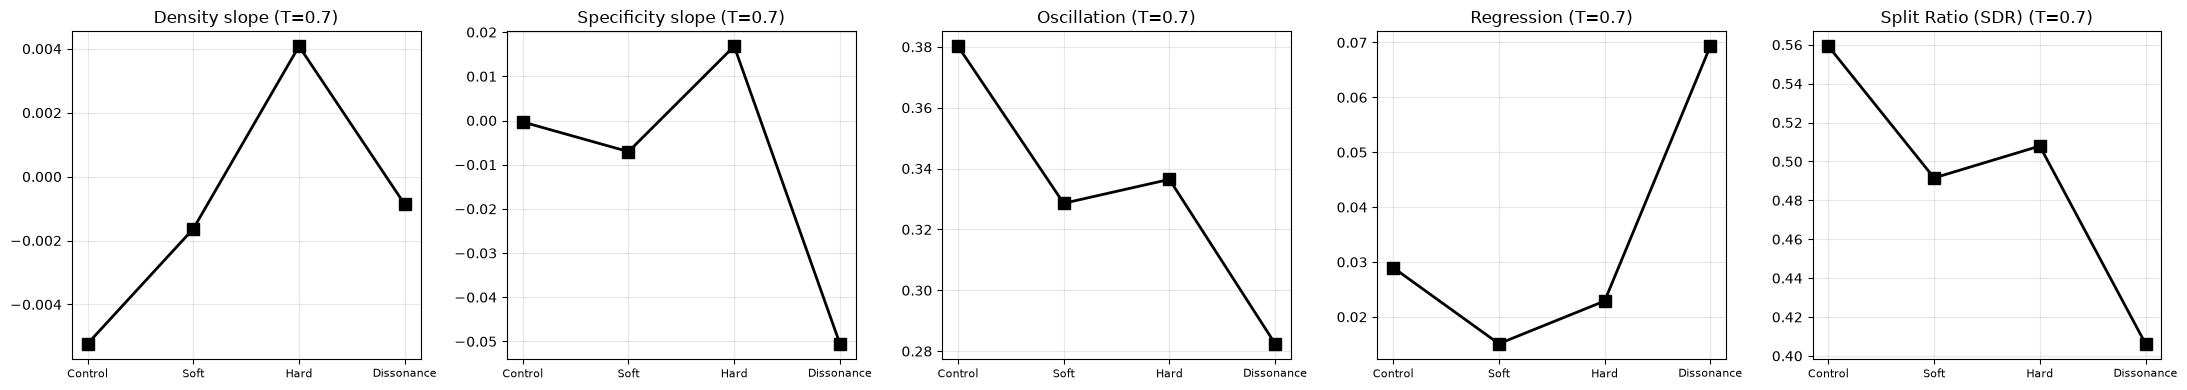

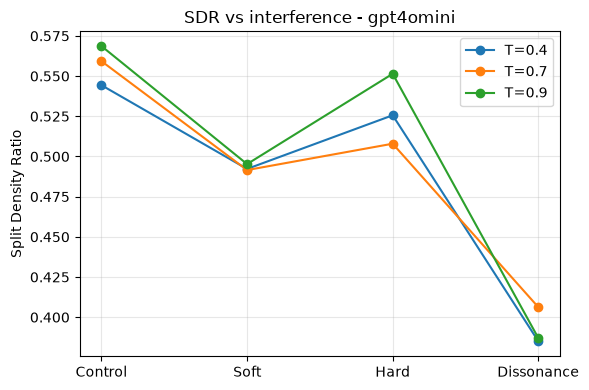

In [10]:
# ── 7. Visualization — Trajectories + SDR temperature ablation ────────────────
level_tick = ['Control', 'Soft', 'Hard', 'Dissonance']

hl = CHAINS_BY_TEMP[HEADLINE_TEMP]
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, key, sk, _d) in zip(axes, SIGNALS):
    means = [np.mean([signal_value(ch, key, sk) for ch in hl if ch['gt_ordinal'] == oi]) for oi in range(4)]
    ax.plot(range(4), means, 'k-s', lw=2, ms=8)
    ax.set_xticks(range(4)); ax.set_xticklabels(level_tick, fontsize=8)
    ax.set_title(f'{name} (T={HEADLINE_TEMP})'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'data/sicd_trajectories_{MODEL_TAG}.png', dpi=150, bbox_inches='tight'); plt.show()

plt.figure(figsize=(6, 4))
for t in TEMPS:
    ch_t = CHAINS_BY_TEMP[t]
    means = [np.mean([signal_value(ch, 'split_density', 'mean_density_ratio') for ch in ch_t if ch['gt_ordinal'] == oi]) for oi in range(4)]
    plt.plot(range(4), means, '-o', label=f'T={t}')
plt.xticks(range(4), level_tick); plt.ylabel('Split Density Ratio')
plt.title(f'SDR vs interference - {MODEL_TAG}'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(f'data/sicd_sdr_ablation_{MODEL_TAG}.png', dpi=150, bbox_inches='tight'); plt.show()
